# Getting started with PROACT

## Introduction

PROACT infers candidate cooperative transcription factor pairs from chromatin accessibility and motif occupancy data using prior-guided
priority-LASSO.
This vignette demonstrates the core workflow using a small example dataset bundled with the package.

## Load PROACT and example data

In [1]:
library(PROACT)

data("PROACT_example")

peak_motif <- PROACT_example$peak_motif
da_peaks <- PROACT_example$da_peaks
expressed_tfs <- PROACT_example$expressed_tfs
target_tfs <- PROACT_example$target_tfs
prior_mat <- PROACT_example$prior_mat

## Prepare the peak × TF matrix

In [2]:
peak_tf <- prepare_peak_tf_matrix(
    peak_motif_mat = peak_motif,
    da_peaks = da_peaks,
    filter_expr = TRUE,
    expr_tfs = expressed_tfs
)

peak_tf$nPeaks
peak_tf$nTFs


Preparing Peak x TF matrix


After peak filtering: 3070 peaks

Removed 37 redundant motif columns

Using minimum motif count = 5

615 TFs retained

166 TFs retained after expression filtering

Final matrix: 3070 peaks x 166 TFs



[1] 3070

[1] 166

## Run PROACT

In [3]:
result <- run_PROACT(
    peak_tf_matrix = peak_tf,
    prior_mat = prior_mat,
    target_tfs = target_tfs,
    ncores = 1
)

head(result)

166 TFs used for priority lasso

46 target TFs retained for modeling

TFDP1: 165 TFs as predictors

TFDP1:5:5:155

EGR1: 164 TFs as predictors

EGR1:6:6:152

ZBTB14: 164 TFs as predictors

ZBTB14:6:158

SP1: 156 TFs as predictors

SP1:34:3:119

TCFL5: 159 TFs as predictors

TCFL5:159

SP3: 158 TFs as predictors

SP3:8:150

KLF12: 156 TFs as predictors

KLF12:14:142

KLF16: 158 TFs as predictors

KLF16:3:20:135

PATZ1: 156 TFs as predictors

PATZ1:7:149

KLF7: 156 TFs as predictors

KLF7:156

KLF6: 158 TFs as predictors

KLF6:3:3:152

ZNF148: 156 TFs as predictors

ZNF148:2:9:145

KLF2: 158 TFs as predictors

KLF2:158

SP4: 156 TFs as predictors

SP4:2:3:151

MAZ: 156 TFs as predictors

MAZ:3:153

KLF4: 156 TFs as predictors

KLF4:4:152

KLF3: 158 TFs as predictors

KLF3:2:16:140

HINFP: 165 TFs as predictors

HINFP:3:162

ZNF740: 164 TFs as predictors

ZNF740:164

ZNF281: 156 TFs as predictors

ZNF281:3:6:147

VEZF1: 164 TFs as predictors

VEZF1:2:2:160

ELK3: 153 TFs as predictors

EL

,TF1,TF2,beta,Cluster1,Cluster2,prior,pairs
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,E2F4,ZBED1,2.8670841,AC0106,AC0039,0,E2F4_ZBED1
2,E2F4,IRF7,1.6766886,AC0106,AC0068,0,E2F4_IRF7
3,E2F4,ZNF24,1.4356356,AC0106,AC0044,0,E2F4_ZNF24
4,E2F4,KLF2,1.4169457,AC0106,AC0113,0,E2F4_KLF2
5,E2F4,NFYA,1.0942958,AC0106,AC0007,0,E2F4_NFYA
6,E2F4,CTCF,0.8425189,AC0106,AC0145,0,CTCF_E2F4


## Plot the network

In [4]:
result$Category <- ifelse(
    result$prior > 0,
    "Prior-supported",
    "No prior"
)

#plot_PROACT_network(result)

Anchor mode: 2 anchor TFs detected in network.



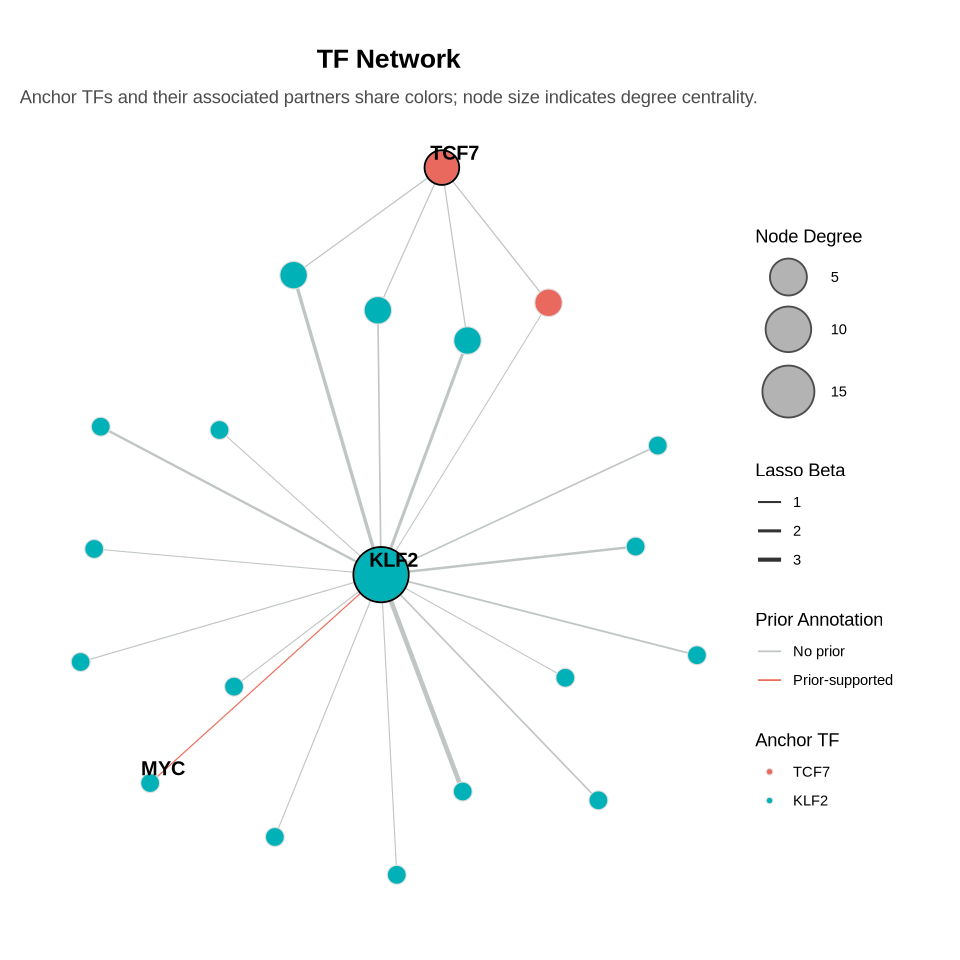

In [5]:
anchor_tfs <- c('TCF7','KLF2')
pair_candidates_sub <- result[result$TF1 %in% anchor_tfs|result$TF2 %in% anchor_tfs,]
options(repr.plot.width = 8, repr.plot.height = 8)
plot_PROACT_network(
    pair_candidates = pair_candidates_sub,
    anchor_tfs = anchor_tfs
)

### Session Information

In [6]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.7 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/handongmei/miniconda3/envs/R4.4/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] PROACT_0.1.0

loaded via a namespace (and not attached):
 [1] shape_1.4.6.1           gtable_0.3.6            ggplot2_4.0.2          
 [4] ggrepel_0.9.8           lattice_0.22-9          vctrs_0.7.2            
 [7] to